In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from sklearn import metrics
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression

import import_ipynb
import preprocessing
print("import successful")

Overwriting requirements.txt

[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10353 entries, 0 to 10352
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Loan ID                       10000 non-null  object 
 1   Customer ID                   10000 non-null  object 
 2   Current Loan Amount           10000 non-null  float64
 3   Term                          10000 non-null  object 
 4   Credit Score                  8019 non-null   float64
 5   Annual Income                 8019 non-null   float64
 6   Years in current job          9573 non-null   object 
 7   Home Ownership                10000 non-null  object 
 8   Purpose                       10000 non-null  object 
 9   Monthly Debt                  100

<string>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


<string>:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform

Categorical: ['Loan Status', 'Term', 'Home Ownership', 'Purpose']
Numerical: ['Current Loan Amount', 'Credit Score', 'Annual Income', 'Years in current job', 'Monthly Debt', 'Years of Credit History', 'Months since last delinquent', 'Number of Open Accounts', 'Number of Credit Problems', 'Current Credit Balance', 'Maximum Open Credit', 'Bankruptcies', 'Tax Liens']
import successful


In [2]:
X_train = pd.read_csv("X_train_scaled.csv")
X_test  = pd.read_csv("X_test_scaled.csv")
y_train = pd.read_csv("y_train.csv")["Loan Status"]
y_test  = pd.read_csv("y_test.csv")["Loan Status"]

print("X_train:", X_train.shape, "X_test:", X_test.shape)
print("y_train:", y_train.shape, "y_test:", y_test.shape)

X_train: (71828, 27) X_test: (17958, 27)
y_train: (71828,) y_test: (17958,)


In [3]:
# TO DO: Initialize the logistic regression model
    
model = LogisticRegression(penalty= "l2", C = 1.0, random_state=16, solver="liblinear", max_iter=1000)


# TO DO: fit the model
model.fit(X_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,16
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [4]:
#TO DO: use predict_proba to get probabilities and make predictions
y_prob = model.predict_proba(X_test)[:,1]
y_pred = (y_prob >= 0.5).astype(int)

In [ ]:
#TO DO: Calculate accuracy using sklearn metrics
# overall correctness
accuracy = metrics.accuracy_score(y_test,y_pred)
print(accuracy)

conf_matrix = metrics.confusion_matrix(y_test, y_pred)
num = conf_matrix[0][0]+conf_matrix[1][1]
denom = conf_matrix[0][0]+conf_matrix[0][1]+conf_matrix[1][0]+conf_matrix[1][1]
print(num/denom)

0.7970263949214834
0.7970263949214834


In [ ]:
#TO DO: Calculate precision using sklearn metrics
# how many predicted positives were correct
precision = metrics.precision_score(y_test,y_pred)
print(precision)

conf_matrix = metrics.confusion_matrix(y_test , y_pred)
num = conf_matrix[1][1]
denom = conf_matrix[1][1]+conf_matrix[0][1]
print(num/denom)

0.7870080830727476
0.7870080830727476


In [ ]:
#TO DO: Calculate recall using sklearn metrics
# how many acutal positives were found
recall = metrics.recall_score(y_test, y_pred)
print(recall)

num = conf_matrix[1][1]
denom = conf_matrix[1][1]+conf_matrix[1][0]
print(num/denom)

0.9973829819051891
0.9973829819051891


In [12]:
#TO DO: Calculate average precision using sklearn metrics
average_precision = metrics.average_precision_score(y_test, y_prob)
print(average_precision)

0.8937751589875849


In [ ]:
#TO DO: Calculate F1 score using sklearn metrics
# combines preicsion and recall into one balanced metric
f1_score = metrics.f1_score(y_test,y_pred)
print(f1_score)

f1 = 2*precision*recall/(precision+recall)
print(f1)

0.8797942156119117
0.8797942156119117


0.212478184991274


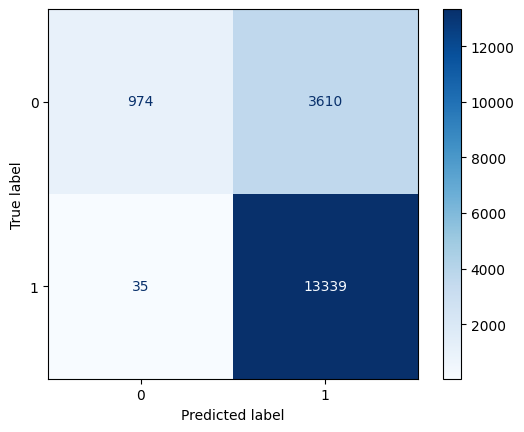

In [13]:
#TO DO: Calculate specificity using confusion matrix

num = conf_matrix[0][0]
denom = conf_matrix[0][0]+conf_matrix[0][1]
print(num/(denom))

#TO DO: Visualize confusion matrix using ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=[0,1])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [14]:
#TO DO: Calculate ROC score

roc_score = metrics.roc_auc_score(y_test, y_prob)
print("ROC AUC SCORE: ", roc_score)

ROC AUC SCORE:  0.74727132964354


AUROC:  0.74727132964354


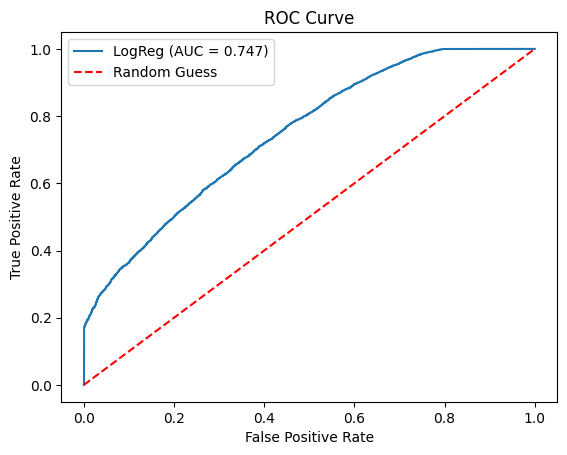

In [15]:
from sklearn.metrics import roc_auc_score, roc_curve

# TO DO: Calculate AUROC

auroc = metrics.roc_auc_score(y_test,y_prob)
print("AUROC: " , auroc)

# TO DO: Plot ROC curve
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_prob)
plt.plot(fpr,tpr,label=f"LogReg (AUC = {auroc:.3f})")
plt.plot([0,1], [0,1],'r--', label= "Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

